In [1]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.odom_only_tb import OdomOnlyTB
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator


/home/david/.cache/pypoetry/virtualenvs/odometry-JJ4jnFPp-py3.11/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")

#setup the datasets
folder_name = "WILK"
# file_name = "WILK_Multipath_Test_1"
# file_name = "WILK_Path_1_No_Dynamic"
file_name = "WILK_Multipath_Test_5"

dataset = radnavDS(
    dataset_path=os.path.join(DATASET_PATH,folder_name,file_name), #_spin_recall
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilkinson.yaml"
)

found 2886 radar samples
found 2886 lidar samples
found 2886 camera samples
found 2886 imu (orientation only) samples
found 2886imu (full data) samples
found 2886 vehicle velocity samples
loaded map from /data/radnav/maps/wilkinson.yaml
loaded map free space from /data/radnav/maps/wilkinson.yaml


In [3]:
lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.1, #was 0.6, try 0.1
    icp_best_points_percentile=50, #was 50 - try 75
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=1.0 #was 0.25, try 1.0
)

loaded map with 20750 points


gt icp estimated heading:-5.708390622483 deg, pose:[-0.06546079  0.21857452]


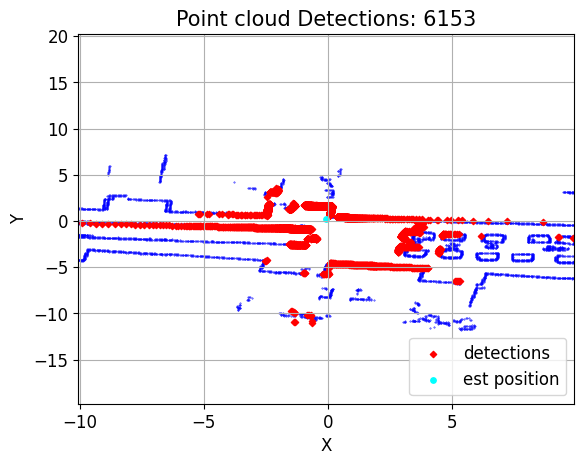

In [4]:
test_bench = OdomOnlyTB(
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset
)

start_heading = np.deg2rad(0)
start_pose = np.array([0.03,0.11])

#initialize the localization
new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

#initialize the filter
test_bench.init_filter(
    est_start_heading_rad=new_heading_rad,
    est_start_position_m=new_pose_m,
    start_time_s=test_bench.get_dataset_start_time(idx=0),
    gyro_bias=-0.0024
)

found temp dir: /home/david/Downloads/radnav_temp_dir
clearing temp directory /home/david/Downloads/radnav_temp_dir


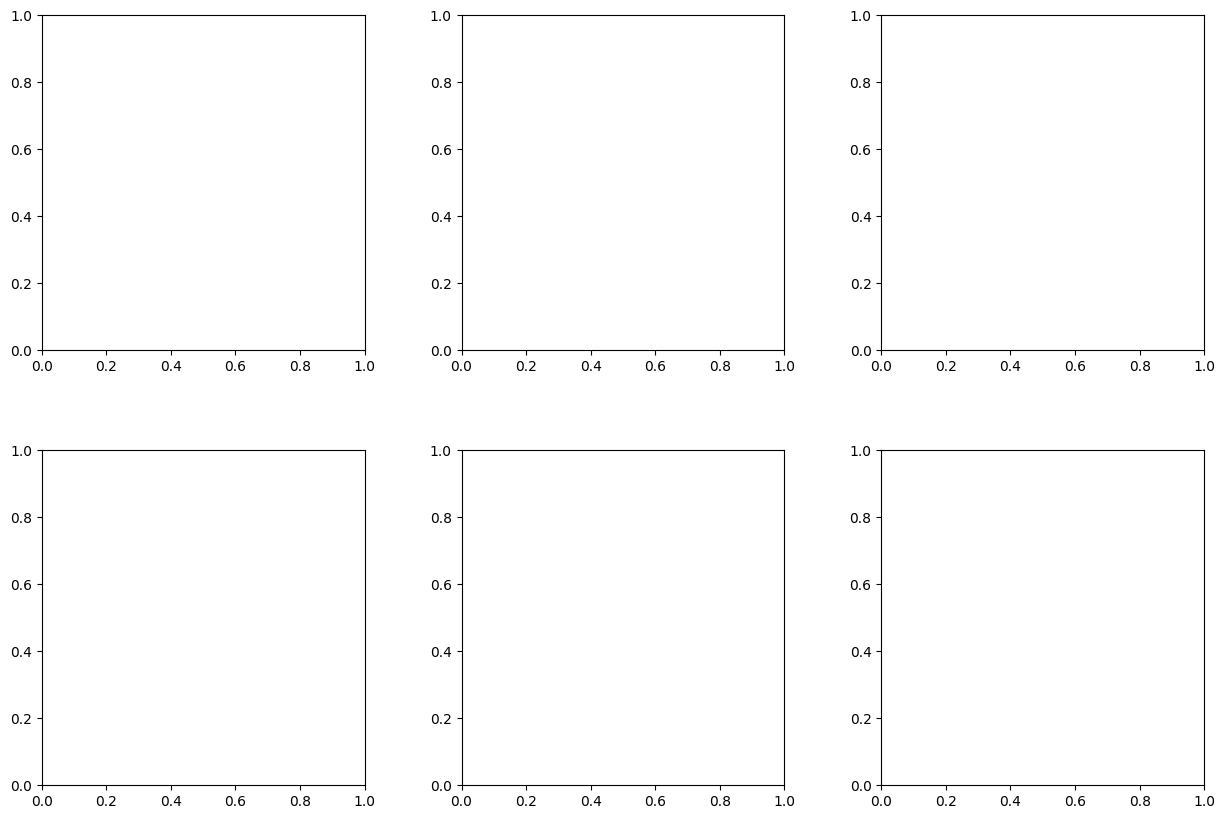

In [5]:
#loading directory from .env file
MOVIE_TEMP_DIRECTORY = os.getenv("MOVIE_TEMP_DIRECTORY")

#initialize the movie maker
movie_generator = MovieGenerator(
    temp_dir_path=MOVIE_TEMP_DIRECTORY
)
movie_generator.initialize_figure(
    nrows=2,
    ncols=3,
    figsize=(15,10)
)

In [6]:
end_idx = dataset.num_frames #dataset.num_frames #point cloud sample: frame 1340 on Wilk_Multipath_test_5
save_name = file_name + "radar_combined"
test_bench.run(
    max_frame=end_idx,
    gt_enabled=True,
    movie_generator=None)

100%|██████████| 2886/2886 [06:12<00:00,  7.75it/s]


In [ ]:
np.save("Trajectories/gt.npy",test_bench.history_position_m_gt)
np.save("Trajectories/odom_only.npy",test_bench.history_position_m)

In [7]:
movie_generator.save_movie(video_file_name="{}.mp4".format(save_name),fps=20)

0it [00:00, ?it/s]


In [8]:
test_bench.analyze(
    save_folder_path="Results",
    file_name=file_name,
    export_to_csv=False
)

,Metric,Absolute position (m),Relative position (m),Absolute heading (deg),Relative heading (deg)
0,Mean,0.789375,0.002389,2.901155,0.024622
1,stdev,0.525586,0.001469,1.532879,0.027786
2,Median,0.658206,0.002297,3.117335,0.015677
3,0.9th percentile,1.685823,0.003969,4.667365,0.062384


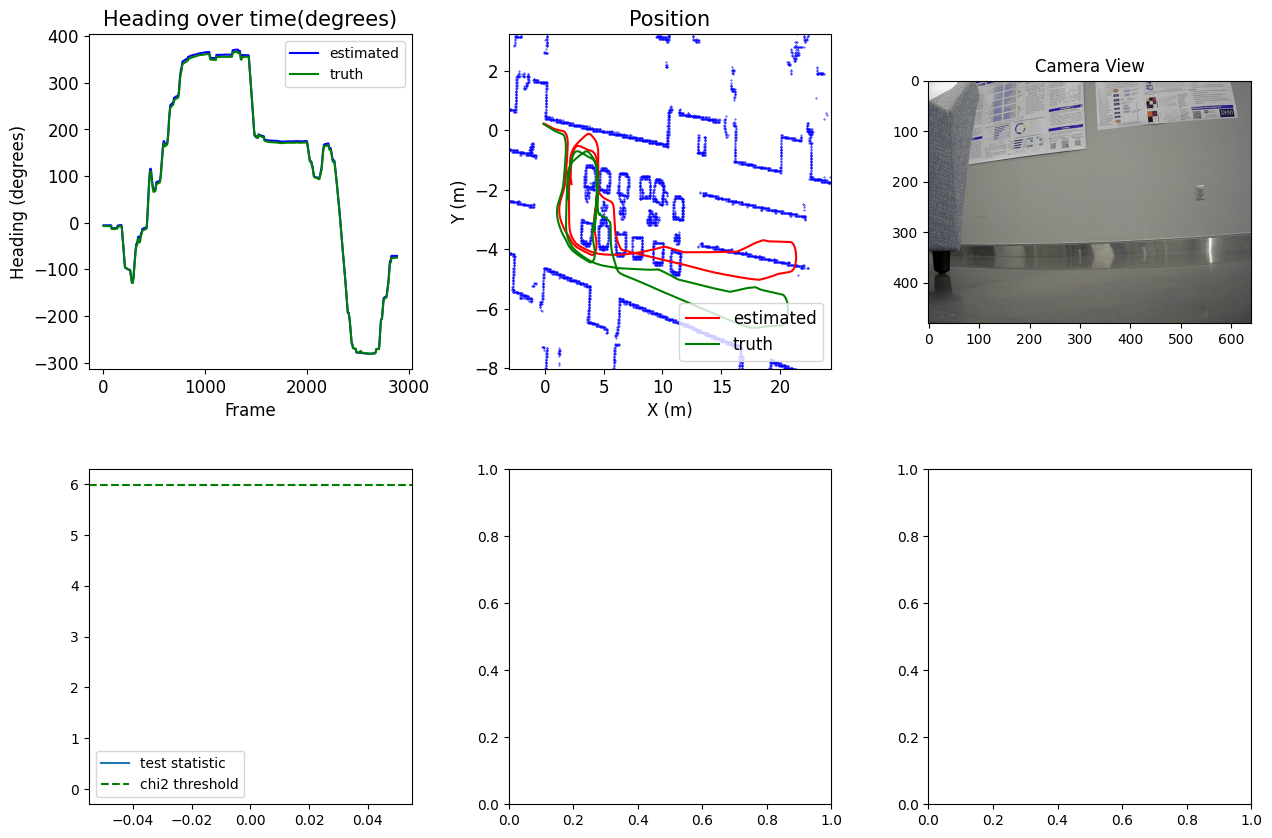

In [9]:
test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)

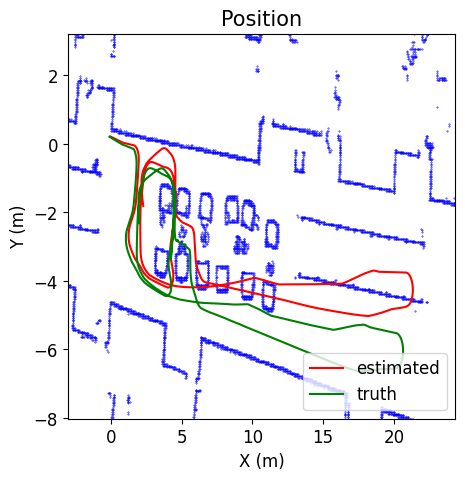

In [10]:
fig, axs = plt.subplots(figsize=(5,5))

test_bench.plotter_localization.plot_position_history_m(
    test_bench.history_position_m,
    test_bench.history_position_m_gt,
    idx=end_idx-1,
    ax=axs,
    show=True
)

fig.savefig("Images/position_history/{}.png".format(save_name))

In [11]:
#compute total distance traveled
dist = 0
for i in range(len(test_bench.history_position_m)-1):
    dist += np.linalg.norm(
        test_bench.history_position_m_gt[i+1] -\
        test_bench.history_position_m_gt[i]
    )

print(dist)

62.09514710533675


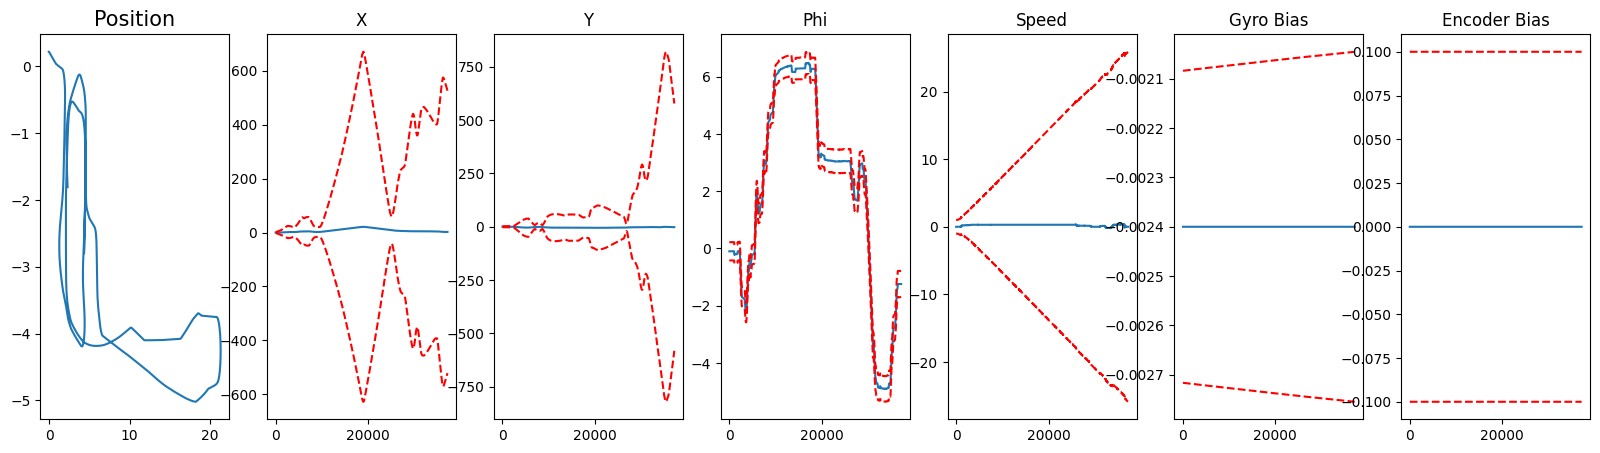

In [12]:
#plot kalman state history
kalman_plotter = PlotterKalman()

kalman_plotter.plot_kalman_result_history(
    x_history=np.array(test_bench.history_filter_est),
    p_history=np.array(test_bench.history_filter_p),
    idx=-1
)



bias: 0.13750987083139757 deg/sec, over 1min: 8.250592249883853 deg


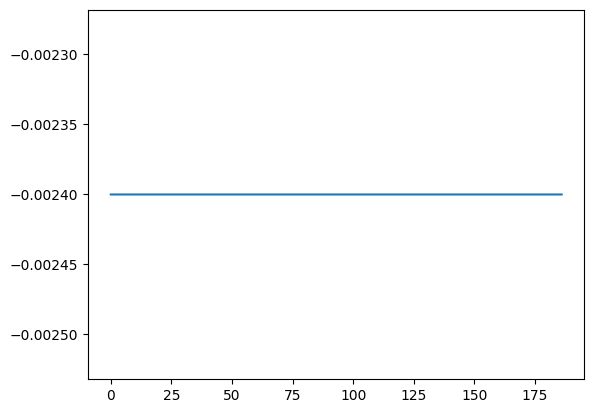

In [13]:
gyro_bias_history = np.array(test_bench.history_filter_est)[:,4]
t = np.arange(0,gyro_bias_history.shape[0]) * 1/200
bias = np.rad2deg(0.0024)
error_due_to_bias = bias * 60
print("bias: {} deg/sec, over 1min: {} deg".format(bias,error_due_to_bias))
plt.plot(t,gyro_bias_history)
